In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [8]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [13]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=2)

In [14]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


## Hyperparameter Optimization

### Best Parameters

- Number of Trees (`n_estimators`): 200
- Maximum Tree Depth (`max_depth`): 30
- Minimum Samples to Split (`min_samples_split`): 5
- Minimum Samples per Leaf (`min_samples_leaf`): 1
- Maximum Features (`max_features`): log2

### Interpretation

RandomizedSearchCV identified the above configuration as the best-performing combination based on 3-fold cross-validation. These hyperparameters improve the model's ability to capture complex relationships while maintaining good generalization performance.

In [15]:
best_model = random_search.best_estimator_

predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 20.23
RMSE: 39.63
R² Score: 0.9142


## Tuned Random Forest Performance

### Results

- MAE: 20.23
- RMSE: 39.63
- R² Score: 0.9142

### Interpretation

- Hyperparameter tuning improved the performance of the Random Forest model.
- The tuned model explains over 91% of the variance in AQI.
- Lower MAE and RMSE indicate more accurate predictions compared to the baseline model.
- Based on these results, the tuned Random Forest model was selected for deployment in the AirCare AI application.

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,PM2.5,0.298612
7,CO,0.224679
2,PM10,0.092234
0,City,0.089148
3,NO,0.070465
4,NO2,0.056175
5,NOx,0.041301
8,SO2,0.037978
11,Toluene,0.021590
9,O3,0.014211


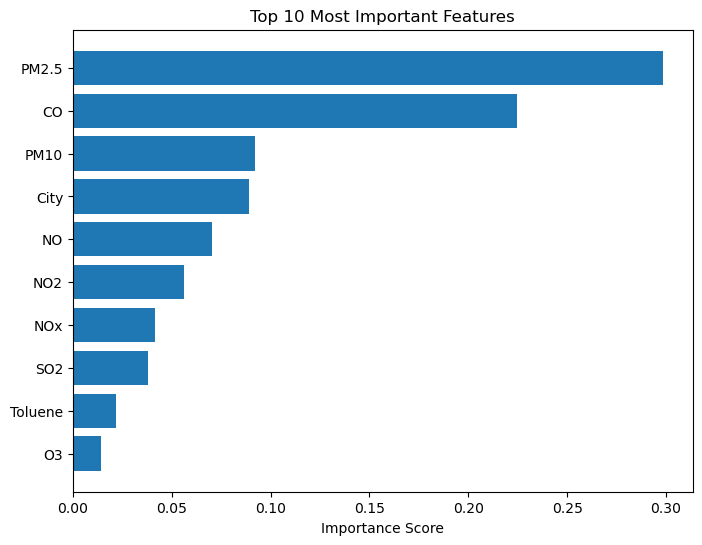

In [18]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.show()

## Feature Importance Analysis

The tuned Random Forest model provides feature importance scores, helping identify which variables contribute most to AQI prediction.

### Key Observations

- PM2.5 is the most influential feature.
- CO and PM10 are also major contributors.
- City has significant importance, indicating location-specific pollution patterns.
- Nitrogen oxides (NO, NO₂, NOx) moderately influence predictions.
- Temporal features (Year and Season) have relatively low importance.

### Conclusion

The feature importance results are consistent with environmental knowledge, where particulate matter (PM2.5 and PM10) plays a major role in determining air quality. This increases confidence that the model has learned meaningful relationships rather than random patterns.

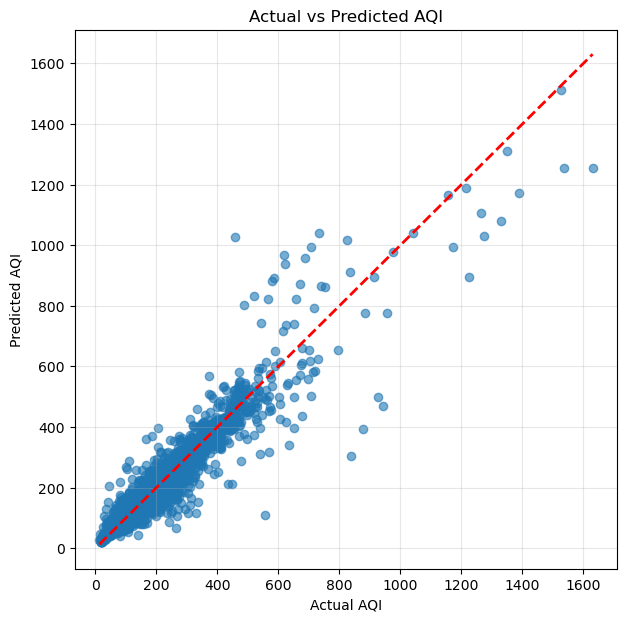

In [19]:
#Actual vs Predicted Plot
plt.figure(figsize=(7, 7))

plt.scatter(y_test, predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.grid(alpha=0.3)

plt.show()

## Actual vs Predicted AQI

The scatter plot compares the actual AQI values with the predicted values from the tuned Random Forest model.

### Observation

- Most points lie close to the diagonal reference line.
- This indicates that the model predicts AQI accurately for the majority of observations.
- A few deviations exist for extreme AQI values, which is expected in real-world environmental datasets.

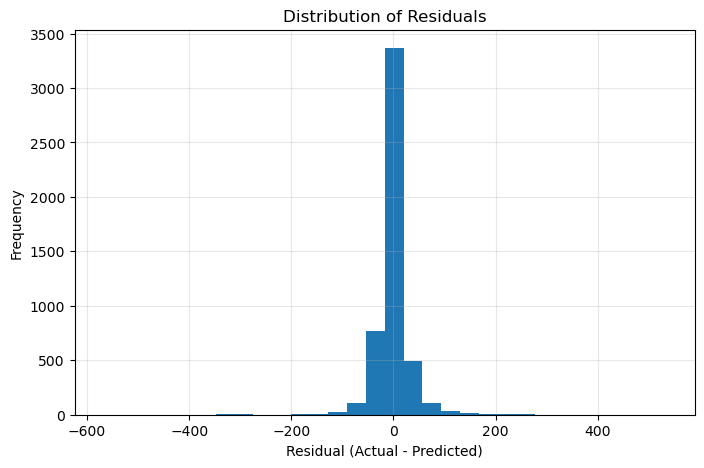

In [20]:
#Residual Analysis
residuals = y_test - predictions
#Histogram
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

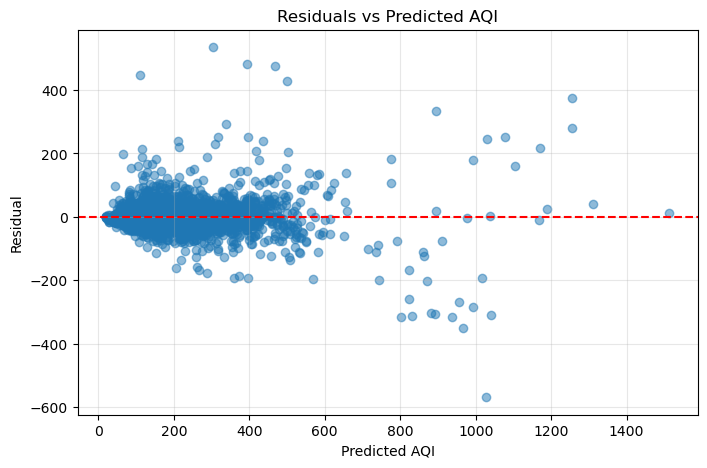

In [21]:
#Residual Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted AQI")

plt.grid(alpha=0.3)

plt.show()

## Residual Analysis

Residual analysis helps evaluate whether prediction errors are randomly distributed.

### Observation

- Residuals are centered around zero.
- No obvious systematic pattern is observed.
- This indicates that the Random Forest model generalizes well without significant prediction bias.

In [22]:
#Save Everything Needed for Deployment
import joblib

joblib.dump(best_model, "../models/aircare_rf_model.pkl")

['../models/aircare_rf_model.pkl']

# Final Model Summary

## Selected Model

Random Forest Regressor (Hyperparameter Optimized)

## Performance

- MAE: 20.23
- RMSE: 39.63
- R² Score: 0.9142

## Key Findings

- Hyperparameter tuning improved model performance.
- PM2.5 is the most influential feature for AQI prediction.
- City-specific information contributes significantly to prediction accuracy.
- The model explains over 91% of the variation in AQI.

## Deployment Decision

The tuned Random Forest model was selected for deployment in the AirCare AI application due to its high predictive accuracy and strong generalization performance.